### Selecting Physical System and Run with Classical ODE Solve Method (20 pts)

Problem: Damped harmonic oscillator

Equation of motion is given by

$$
\begin{gather*}
m\ddot{x}=-kx-b\dot{x}\\
\ddot{x}+2\gamma\dot{x}+\omega^2x=0
\end{gather*}
$$
with $\omega_0^2=k/m$ and $\gamma=b/(2m)$. We can solve this problem using ansatz: $x(t)=e^{\lambda t}$. Therefore,
$$
\begin{align*}
(\lambda^2+2\gamma\lambda+\omega_0^2)x=0
\end{align*}
$$
The non trivial solution is given as
$$
\begin{gather*}
\lambda=-\gamma\pm\sqrt{\gamma^2-\omega_0^2}\\
\therefore x(t)=Ae^{(-\gamma+\sqrt{\gamma^2-\omega_0^2})t} + Be^{(-\gamma-\sqrt{\gamma^2-\omega_0^2})t}
\end{gather*}
$$
In this note, we treat only underdamped case, $\gamma^2<\omega_0^2$. Defining $\omega=\sqrt{\omega_0^2-\gamma^2}$, we have the general solution as
$$
\begin{align*}
x(t)=Ae^{(-\gamma+i\omega)t} + Be^{(-\gamma-i\omega)t}=e^{-\gamma t}(Ae^{i\omega t}+Be^{-i\omega t})=Ce^{-\gamma t}\cos(\omega t+\phi)
\end{align*}
$$
Here, $C$ and $\phi$ will be determined by initial conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# INITIAL CONDITIONS
x0 = 2.0 # Initial condition of x
v0 = 1.0 # Initial condition of v
w0 = 20.0 # \omega_0
g = 2.0 # \gamma
w = np.sqrt(w0**2 - g**2) # \omega=\sqrt{\omega_0^2-\gamma^2}

# ODE FUNCTION

def f(r, t, w0, g):
    r_new = np.zeros((r.shape[0]), dtype=float)
    r_new[0] = r[1]
    r_new[1] = -w0*w0*r[0] - 2*g*r[1]

    return r_new

In [2]:
# SELECTED CLASSICAL METHOD FOR SOLVING ODE: RK4

def RK4(f, r, t, h, w0=w0, g=g):
    k1 = h*f(r, t, w0, g)
    k2 = h*f(r + 0.5*k1, t + 0.5*h, w0, g)
    k3 = h*f(r + 0.5*k2, t + 0.5*h, w0, g)
    k4 = h*f(r + k3, t + h, w0, g)

    return r + (k1 + 2*k2 + 2*k3 + k4)/6.0

In [3]:
# SOLVE ODE
h = 0.01 # Time step
t = np.arange(0, 1+h, h) # Time
r = np.zeros((2, t.size), dtype=float)
# r[0] = x, position
# r[1] = v, velocity
r[0, 0] = x0
r[1, 0] = v0

for i, t_i in enumerate(range(t.size - 1)):
    r[:, i+1] = RK4(f, r[:, i], t_i, h)


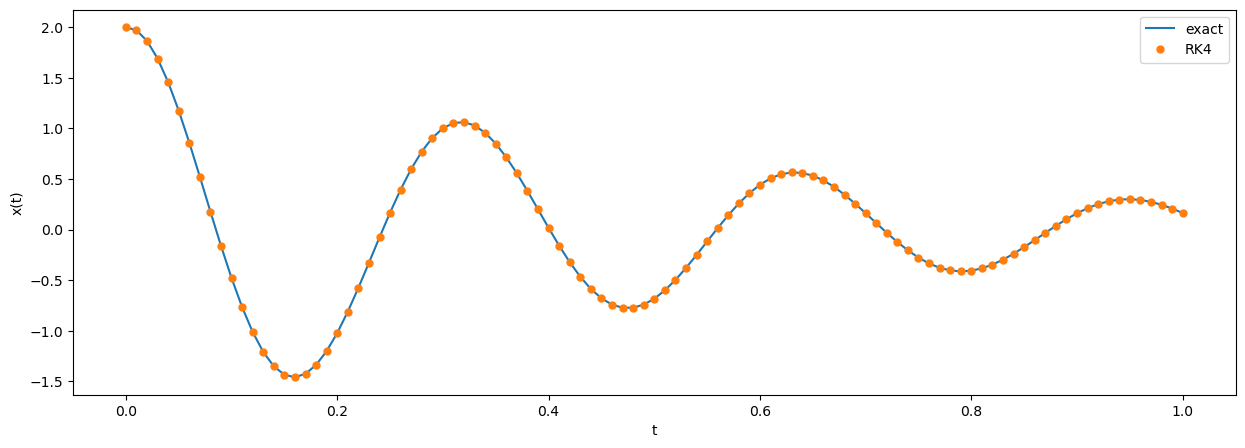

In [4]:
# VISUALIZATION
phi = np.arctan(-(g + v0/x0)/w)
C = x0/np.cos(phi)
x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

plt.figure(figsize=(15, 5))
plt.plot(t, x_exact, label="exact")
plt.plot(t, r[0], 'o', markersize=5, label="RK4")
#plt.plot(t, r[0], '--', label="RK4")
plt.xlabel("t")
plt.ylabel("x(t)")

plt.legend()
plt.show()


### Run with Simple NN (20pts)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(123)

# SELECTED NEURAL NETWORK FOR SOLVING ODE

pinn_net = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
    )

In [22]:
# DEFINE RESIDUAL FUNCTION

def Residual(net, t_init, t_input, x0, v0, w0, g):
    '''
    net: neural newtork
    t_init: t for initial conidition
    t_input: t for propagation
    x0: Initial value of x
    v0: Inivial value of v
    w0, g: ODE parameters
    '''
    # loss for initial condition
    # dx/dt
    x_init = net(t_init)
    v0_pred = torch.autograd.grad(x_init, t_init, torch.ones_like(x_init), create_graph=True)[0]

    loss_init = (x_init.squeeze() - x0)**2 + 1e-1*(v0_pred.squeeze() - v0)**2

    # loss for ODE
    # dx/dt
    x_pred = net(t_input)
    dx = torch.autograd.grad(x_pred, t_input, torch.ones_like(x_pred), create_graph=True)[0]
    #d^2x/dt^2
    ddx = torch.autograd.grad(dx, t_input, torch.ones_like(dx), create_graph=True)[0]

    loss_ode = 1e-4*torch.mean((ddx + 2*g*dx + w0*w0*x_pred)**2)

    return loss_ode + loss_init

In [23]:
# DATASET GENERATION

t_init = torch.zeros([1, 1]).requires_grad_(True) # t for initial conidition
t_input = torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True) # t for propagation

Epoch 100/15000, Loss: 1.0101372254212038e-06
Epoch 200/15000, Loss: 2.834835868270602e-06
Epoch 300/15000, Loss: 1.133295342015117e-07
Epoch 400/15000, Loss: 7.054454442823044e-08
Epoch 500/15000, Loss: 1.4128837619864498e-06
Epoch 600/15000, Loss: 3.765742917494208e-08
Epoch 700/15000, Loss: 3.12795336299132e-08
Epoch 800/15000, Loss: 7.732884910183202e-07
Epoch 900/15000, Loss: 4.1598990918600975e-08
Epoch 1000/15000, Loss: 3.346163524042822e-08
Epoch 1100/15000, Loss: 3.2712669906231895e-08
Epoch 1200/15000, Loss: 3.5687162380781956e-07
Epoch 1300/15000, Loss: 3.9802433349223065e-08
Epoch 1400/15000, Loss: 3.8696519766290294e-08
Epoch 1500/15000, Loss: 3.772467493945442e-08
Epoch 1600/15000, Loss: 4.6305544856295455e-06
Epoch 1700/15000, Loss: 1.0067253697343403e-06
Epoch 1800/15000, Loss: 5.357268051398023e-08
Epoch 1900/15000, Loss: 5.020418925028025e-08
Epoch 2000/15000, Loss: 8.826069097267464e-05
Epoch 2100/15000, Loss: 7.811124760337407e-07
Epoch 2200/15000, Loss: 5.136227088

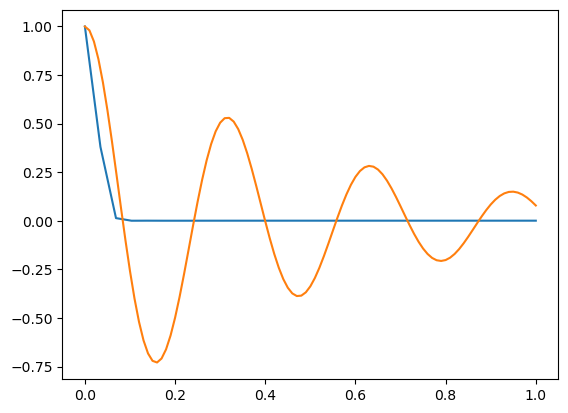

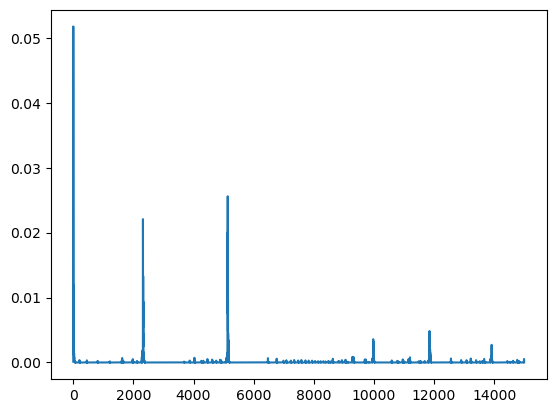

In [24]:
# TRAINING NEURAL NETWORK
epochs = 15000
loss_list = np.zeros(epochs, dtype=float)
optimizer = optim.Adam(pinn_net.parameters(), lr=1e-3)
x0 = 1
v0 = 0

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = Residual(pinn_net, t_init, t_input, x0, v0, w0, g)
    loss.backward()
    optimizer.step()
    loss_list[epoch] = loss.item()


    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")


with torch.no_grad():
    phi = np.arctan(-(g + v0/x0)/w)
    C = x0/np.cos(phi)
    x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

    x_pred = pinn_net(t_input)
    plt.plot(t_input, x_pred, label="PINN")
    plt.plot(t, x_exact, label="exact")
    plt.show()

    plt.plot(loss_list)
    plt.show()


### Analysis Classical Method and Deep Learning Based Method (30pts)

YOUR SELECTED ANALYSIS METHOD (OR ANALYSIS PARAMETERS) EXPLANATION HERE (in markdown)

In [ ]:
# ANALYSIS

# YOUR ANALYSIS CODE HERE

In [ ]:
# VISUALIZATION

# YOUR VISUALIZATION FOR ANALYSIS CODE HERE

### Discuss the results (30pts)

DISCUSSING THE ANALYSIS RESULTS (in 200 words)